## Capgemini Case : O-Zone Telecome

## Data  Import & Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

We start by loading the employee dataset and checking its shape.
This confirms the data scope and ensures we are working at the right granularity (one row per employee).

In [5]:
df = pd.read_csv("employee (1).csv")

print("Dataset shape (rows, columns):", df.shape)
display(df.head(5))

Dataset shape (rows, columns): (1518, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,3,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,5,...,4,80,1,6,3,3,2,2,2,2


The dataset contains 1,518 employees and 35 variables, providing enough coverage to analyze attrition patterns and employee profiles.

Mixed types (numeric + categorical)

Target = Attrition (Yes/No)

## Data audit to look types, missing values, duplicates

Before modeling, we validate data quality:
- variable types (numeric vs categorical)
- missing values (risk of bias)
- duplicates (data integrity)

It's important to mention that in consulting, this is a crucial step because the recommendations must be based on reliable, qualitative data (one of Capgemeni value also).

In [6]:
df["AttritionFlag"] = df["Attrition"].map({"Yes":1, "No":0})

print("Attrition rate:", round(df["AttritionFlag"].mean()*100,2), "%")

Attrition rate: 16.34 %


## Data audit (data credibility check)

Before analyzing drivers, we verify data integrity:
- variable types (numeric vs categorical)
- missing values (risk of bias)
- duplicates (data quality)
This ensures our findings are reliable and reproducible.


In [7]:
dtype_counts = df.dtypes.value_counts()
print("Data types:\n", dtype_counts)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

audit = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
display(audit[audit["missing"] > 0].head(20))

dup = df.duplicated().sum()
print("Duplicate rows:", dup)

Data types:
 int64    27
str       9
Name: count, dtype: int64


,missing,missing_%


Duplicate rows: 0


With this step, we know that we got 27 variables with 9 categorical. Furthermore, we just checked that we have no missing values and no duplicates row which is highly important to reduce mistake of our analysis.

## Attrition concentration analysis - by Departement

Now that data quality is validated, we analyze where attrition concentrates.

If attrition is uneven across departments or overtime groups, 
this immediately reveals structural operational risk areas.

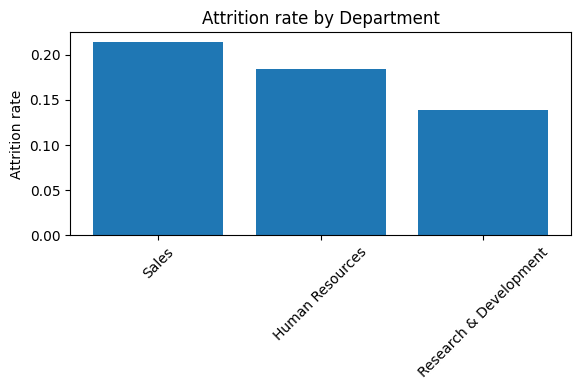

Department
Sales                     0.214
Human Resources           0.185
Research & Development    0.139
Name: AttritionFlag, dtype: float64

In [8]:
dept_attr = df.groupby("Department")["AttritionFlag"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(dept_attr.index, dept_attr.values)
plt.title("Attrition rate by Department")
plt.ylabel("Attrition rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(dept_attr.round(3))

Interpretation — Department Risk

Attrition by department:

Sales → 21.4%

HR → 18.5%

R&D → 13.9%

Company average → 16.34%

Consultant interpretation:

Sales is clearly the most exposed department

+5 percentage points vs R&D

~30% higher attrition than R&D

R&D is relatively stable.

HR is above company average.

## Attrition by Overtime

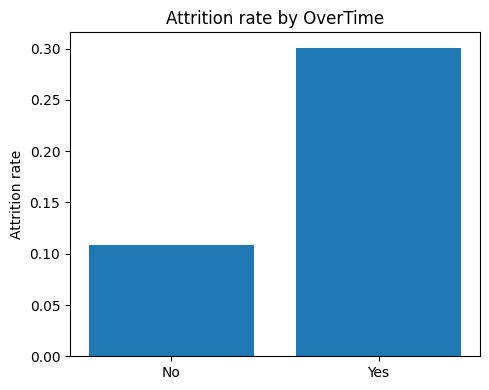

OverTime
No     0.109
Yes    0.301
Name: AttritionFlag, dtype: float64

In [9]:
ot_attr = df.groupby("OverTime")["AttritionFlag"].mean()

plt.figure(figsize=(5,4))
plt.bar(ot_attr.index, ot_attr.values)
plt.title("Attrition rate by OverTime")
plt.ylabel("Attrition rate")
plt.tight_layout()
plt.show()

display(ot_attr.round(3))


We are noticing here a structural risk. Indeed, the results is showing us:
Interpretation — Overtime Effect

Attrition:

No overtime → 10.9%

Overtime → 30.1%

Company average → 16.34%

In a consultant role interpretation, this means that Attrition is strongly associated with overtime exposure. Employees working overtime show a 30% attrition rate versus 11% for non-overtime employees, indicating workload stress as a major structural risk.

## Numeric driver comparison (Leavers vs Stayers)

We now compare key operational variables between:
- Employees who left (Attrition = 1)
- Employees who stayed (Attrition = 0)

This helps identify structural differences beyond categorical segments.

In [10]:
key_vars = [
    "MonthlyIncome",
    "YearsAtCompany",
    "DistanceFromHome",
    "JobSatisfaction",
    "WorkLifeBalance",
    "YearsSinceLastPromotion"
]

comparison = df.groupby("AttritionFlag")[key_vars].mean().round(2)
display(comparison)

,MonthlyIncome,YearsAtCompany,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsSinceLastPromotion
AttritionFlag,,,,,,
0,6839.74,7.36,8.92,2.78,2.77,2.22
1,4807.36,5.12,10.58,2.45,2.67,1.98


Concretly, this table tells us here that the compnsation effect is very strong. Indeed, the leavers earn 2000 less per month on average. We can say that this is a major gap so compensation is likely a strong driver.

For the tenure effect, leavers data shows a shorter tenur for leavers this suggests early-career attrition, poor onboarding, weak first-year engagement.

Finally, out code results tells us that leavers live farther away so distance friction does matter. 

Nevertheless, job satifaction is lower among leavers

As a summary of this section, we can resume that attrition is associated with:

Overtime exposure (major structural driver)

Lower income

Shorter tenure

Longer commute

Lower satisfaction

This is already a coherent risk model.

## Data preparation for PCA & clustering

We prepare a clean feature matrix:

- Remove target variable (Attrition)
- Remove identifiers / constants
- Encode categorical variables
- Standardize all variables

Clustering must not use attrition to avoid leakage.


In [11]:
drop_cols = ["Attrition", "AttritionFlag", "EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"]
drop_cols = [c for c in drop_cols if c in df.columns]

X_raw = df.drop(columns=drop_cols)

cat_cols = X_raw.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

X = X.fillna(X.median(numeric_only=True))

print("Final clustering matrix shape:", X.shape)


Final clustering matrix shape: (1518, 44)


C:\Users\PC\AppData\Local\Temp\ipykernel_31712\3618611365.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include=["object"]).columns


With this step, we know notice having 1518 employees and 44 fetaures after encoding so we are going to look for real dimensionality control step.

## Step 5 — Standardization and PCA

We standardize variables to ensure equal contribution in Euclidean distance.
Then we apply PCA to:

- Reduce dimensionality
- Remove multicollinearity
- Improve clustering stability

A important note on the scaling part with this step because if we don't to this: income dominates, tenure dominates and everything else becomes irrelevant.

We will need KMeans that uses Euclidean distance.

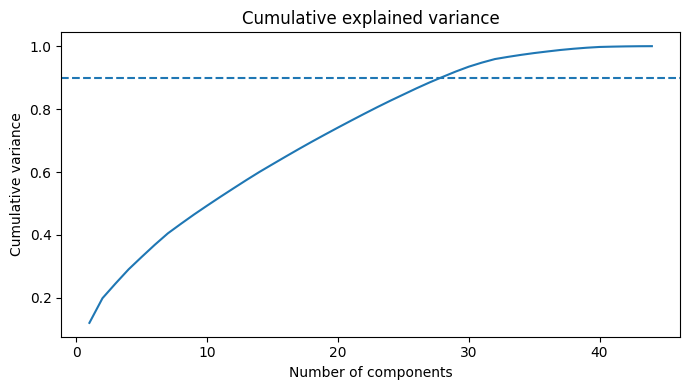

Number of PCA components retained: 28
Total variance explained: 0.9022


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=42)
PC_full = pca_full.fit_transform(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(0.90, linestyle="--")
plt.title("Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.tight_layout()
plt.show()

pca = PCA(n_components=0.90, random_state=42)
PC = pca.fit_transform(X_scaled)

print("Number of PCA components retained:", PC.shape[1])
print("Total variance explained:", round(pca.explained_variance_ratio_.sum(), 4))


PCA Interpretation

44 original features

Reduced to 28 principal components

Retains 90.22% of total variance

Consultant-level meaning:

We reduced dimensionality by ~36%
while preserving most workforce information.

Concretly, this reduces noise, improves clustering stability, avoids multicollinearity distortions and makes Euclidean distance meaningful

## Determining optimal number of clusters (K)

We use two criteria:

1) Elbow method (WCSS — within-cluster sum of squared Euclidean distances)
2) Silhouette score (cluster separation quality)

Goal: balance statistical validity and business interpretability.

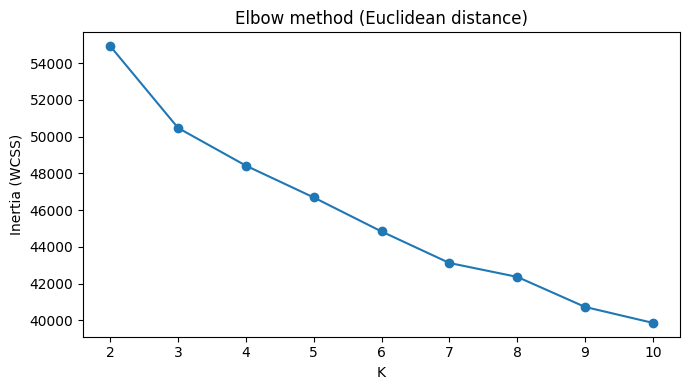

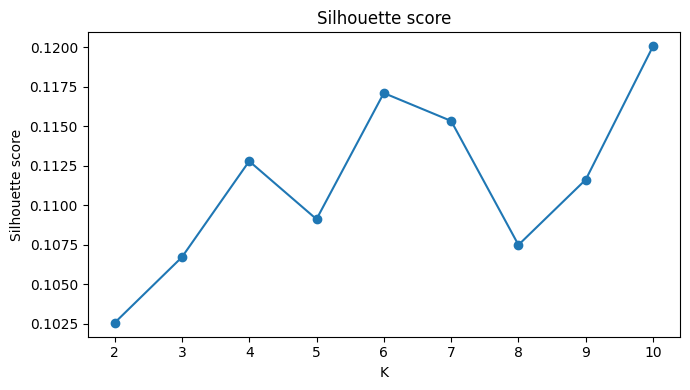

,K,Inertia,Silhouette
0,2,54919.446280,0.102558
1,3,50467.200635,0.106714
2,4,48414.854152,0.112790
3,5,46684.196855,0.109119
4,6,44831.615731,0.117101
5,7,43117.555451,0.115335
6,8,42361.438233,0.107491
7,9,40725.381602,0.111623
8,10,39857.311704,0.120066


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(PC)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(PC, labels))

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow method (Euclidean distance)")
plt.xlabel("K")
plt.ylabel("Inertia (WCSS)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.title("Silhouette score")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

scores_table = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": sil_scores
})

display(scores_table)

As a analysis interpretation of our elbow method result (WCSS), the curve shows:
### Elbow interpretation (WCSS)

Indeed, the elbow curve shows a strong reduction in within-cluster variance from K=2 to K=3, and a noticeable on top improvement up to K=4. Beyond K=4, the marginal gains become progressively smaller and the curve starts to stay flat, suggesting diminishing returns from adding more clusters. Therefore, K=4 appears to be the most coherent choice from an optimization standpoint while remaining actionable for HR decision-making.

### Silhouette interpretation

Silhouette scores remain relatively low across all tested values of K (approximately 0.10–0.12), indicating moderate cluster separation. This is expected in HR datasets, where employee profiles tend to overlap rather than form sharply distinct groups.

Although the highest silhouette value appears at higher K values, the incremental improvements remain limited and do not justify increased segmentation complexity. Importantly, from a business perspective, overly granular segmentation reduces interpretability and strategic usability.

Therefore, combining the silhouette analysis with the elbow method and business interpretability criteria, K=4 provides the most balanced and actionable segmentation structure.


### Final cluster selection

From a consulting perspective, the objective is not to maximize mathematical separation at any cost, but to identify a segmentation that remains statistically sound while being strategically actionable.

The elbow analysis indicates that the most significant reduction in within-cluster variance occurs between K=2 and K=4, after which marginal improvements diminish. Although higher K values slightly increase the silhouette score, these gains remain limited and do not justify additional segmentation complexity.

In this logic, we select K = 4 as the optimal number of clusters. This choice ensures:

- Sufficient statistical separation  
- Clear and interpretable employee profiles  
- Actionable segmentation for executive decision making  

## Final KMeans clustering (K = 4)

Based on elbow and silhouette analysis, we select K = 4 as the most balanced and relevant/actionable segmentation structure.

Cluster
0    845
1    260
2     88
3    325
Name: count, dtype: int64

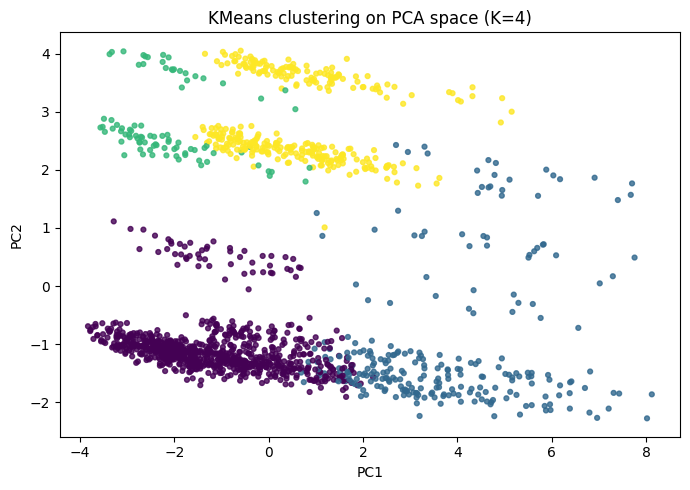

In [14]:
K_opt = 4

kmeans = KMeans(n_clusters=K_opt, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(PC)

cluster_sizes = df["Cluster"].value_counts().sort_index()
display(cluster_sizes)

plt.figure(figsize=(7,5))
plt.scatter(PC[:,0], PC[:,1], c=df["Cluster"], s=12, alpha=0.8)
plt.title("KMeans clustering on PCA space (K=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### Interpretation

We can then interpret all cluster and characterize them:

- Cluster 0 represents the largest population segment (845 employees), corresponding to the core workforce.

- Clusters 3 and 1 represent medium-sized segments (325 and 260 employees), indicating meaningful subgroups with sufficient scale for targeted HR strategies.

- Cluster 2 is a smaller niche segment (88 employees), likely representing a more specific employee profile that may require focused managerial attention.

Although the clusters are not perfectly balanced there is no extreme imbalance and each segment remains statistically significant and operationally usable.

## Attrition rate by cluster

We compute attrition rate within each cluster to identify high-risk employee profiles.


Cluster
0    0.166
1    0.058
2    0.420
3    0.172
Name: AttritionFlag, dtype: float64

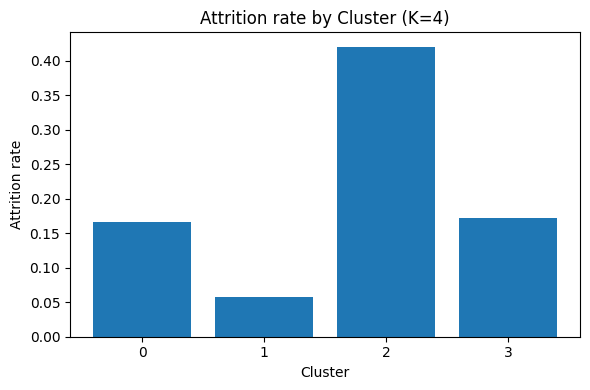

In [20]:
attr_by_cluster = df.groupby("Cluster")["AttritionFlag"].mean()

display(attr_by_cluster.round(3))

plt.figure(figsize=(6,4))
plt.bar(attr_by_cluster.index.astype(str), attr_by_cluster.values)
plt.title("Attrition rate by Cluster (K=4)")
plt.xlabel("Cluster")
plt.ylabel("Attrition rate")
plt.tight_layout()
plt.show()

### Attrition Risk Segmentation: Strategic Interpretation

The clustering results reveal a clearly differentiated attrition structure across employee segments.

Cluster 2 emerges as the critical-risk segment, with an attrition rate of 42.0%, which is approximately 2.5 times higher than the company average (around 16%) and significantly higher than the safest segment. This cluster represents a structurally unstable employee group requiring immediate managerial attention and targeted retention initiatives.

Cluster 0 (16.6%) and Cluster 3 (17.2%) display attrition levels close to the company average. These segments can be considered moderate-risk groups. While not alarming, they should remain under monitoring to prevent potential deterioration.

Cluster 1 shows a very low attrition rate of 5.8%, making it the most stable segment within the organization. This cluster likely reflects strong retention drivers that could be replicated across other employee groups.

Overall, the segmentation successfully distinguishes between low-risk, moderate-risk, and critical-risk employee profiles. This structure provides a clear and actionable foundation for HR strategy, enabling targeted interventions rather than uniform retention policies.

## Cluster profiling (what defines each segment)

We compute average values of key variables by cluster to understand:

- Compensation differences
- Tenure differences
- Distance differences
- Satisfaction differences

This allows naming clusters and building action plans.


In [16]:
profile_vars = [
    "MonthlyIncome",
    "YearsAtCompany",
    "DistanceFromHome",
    "JobSatisfaction",
    "WorkLifeBalance",
    "YearsSinceLastPromotion",
    "Age"
]

cluster_profile = df.groupby("Cluster")[profile_vars].mean().round(2)
display(cluster_profile)

,MonthlyIncome,YearsAtCompany,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsSinceLastPromotion,Age
Cluster,,,,,,,
0,4185.80,5.29,9.15,2.73,2.73,1.47,35.07
1,14985.17,13.65,8.93,2.66,2.72,4.73,46.11
2,2641.16,3.02,8.74,2.75,2.86,1.08,30.62
3,6809.61,7.18,9.65,2.75,2.82,2.32,36.59


So, thanks to our table results for cluster profiling, we are going to characterize and define each cluster:

First, for cluster 2 (so critical risk with 42% attrition); it shows an income of 2,641 (lowest of all clusters). For the tenure: 3.02 years (very short), for the age: 30.6 (youngest) and for the promotion gap: low (1.08).

With all these information, we understand that satisfaction is not extremely low. We can interpretate that this is clearly Young, low-paid, early-career employees.

So, in summary, they are:Early-stage

Underpaid

High turnover segment

This is likely junior or entry-level roles.

This particular cluster is presented as the structural churn engine.

Secondly, for the cluster 0 (so moderate risk and 16.6%)

Its profile shows an income of 4,186; a tenure of 5.29 years and age of 35.07. Here, the promotion gap is also relatively low (1.47).

For the interpretation, these are:

Mid-level employees plateauing in career progression.

Risk here may be:Career stagnation

Third cluster profile: Cluster 1 (which is very safe with 5.8% attrition)

For this cluster, the profile demonstrates an income of 14,985, a tenure of 13.65 years and age is 46.11.

However here, the promotions is 4.73 years since last.

For the interpretation, these are:

Most likely senior, highly paid, stable workforce

Low attrition.

Concretely, this is an anchor population.

For the final cluster 3 (with moderate risk, 17.2% attrition), its profile tell a Medium income (6,809)

a Mid tenure (7.18 years)

Age of 36.59

Promotion gap of 2.32

Stable experienced employees in mid-career stage.

We can then conclude that attrition is not random.

In fact, it is based in:

Young, low-income, short-tenure employees (Cluster 2)

Mid-career plateau employees (Cluster 0)

Stable workforce segments are senior high-income employees (Cluster 1) and experienced mid-career employees with stronger stability (Cluster 3).

## Predictive modeling (Random Forest)

Clustering identifies profiles.
Random Forest quantifies which variables drive attrition risk.

This validates and prioritizes operational levers.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

y = df["AttritionFlag"]

drop_cols_model = ["Cluster", "Attrition", "AttritionFlag",
                   "EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"]
drop_cols_model = [c for c in drop_cols_model if c in df.columns]

X_model = df.drop(columns=drop_cols_model)

X_model = pd.get_dummies(X_model, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(X_train, y_train)

proba_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest ROC AUC:", round(roc_auc_score(y_test, proba_rf), 3))

Random Forest ROC AUC: 0.809


## Predictive modeling (Random Forest)

To continue, the clustering does identifies structural employee profiles.
Random Forest modeling quantifies which variables statistically drive attrition risk.

The model achieves a ROC AUC of 0.809, indicating strong predictive power. This means that the model can correctly rank a randomly selected leaver above a stayer approximately 81% of the time.

From a consulting perspective, this confirms that:

- Attrition is not random
- Structural and measurable drivers exist
- The segmentation insights are statistically supported

Importantly, this enables HR to move from descriptive segmentation to predictive risk management.

Finally, we need to dentify the top drivers.

MonthlyIncome               0.093819
TotalWorkingYears           0.084659
Age                         0.082497
OverTime_Yes                0.079695
YearsWithCurrManager        0.051697
YearsAtCompany              0.051041
DailyRate                   0.039312
StockOptionLevel            0.038385
DistanceFromHome            0.032858
MonthlyRate                 0.030236
HourlyRate                  0.027762
RelationshipSatisfaction    0.027486
MaritalStatus_Single        0.027476
JobLevel                    0.027126
YearsInCurrentRole          0.025686
dtype: float64

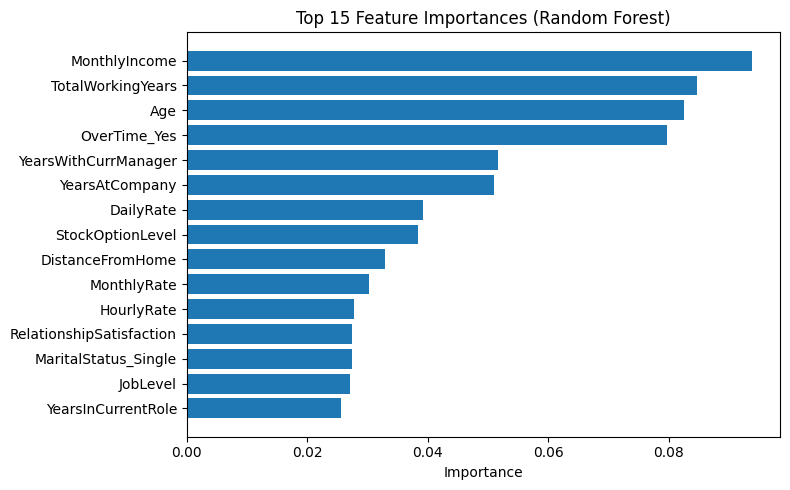

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_model.columns)
importances = importances.sort_values(ascending=False)

top_15 = importances.head(15)

display(top_15)

plt.figure(figsize=(8,5))
plt.barh(top_15.index[::-1], top_15.values[::-1])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Model Performance

Random Forest ROC AUC = 0.809

Indeed, it shows:

- Strong predictive power (the model correctly ranks leavers above stayers approx. 81% of the time)

- Attrition is structurally explainable through measurable variables

- Structural drivers such as income, tenure, age and overtime significantly influence turnover risk

This statistically validates the segmentation findings identified in the clustering phase

The feature importance analysis confirms that attrition is primarily driven by:

- Compensation level (MonthlyIncome)

- Experience and tenure (TotalWorkingYears, YearsAtCompany)

- Age

- Overtime exposure

This reinforces the conclusion that turnover risk is concentrated among younger, lower-paid, shorter-tenure employees, while senior and higher-income profiles remain structurally stable.

Overall, the predictive modeling phase strengthens the strategic conclusion: attrition is not random, and targeted HR interventions can be designed around clearly identified operational levers.

### Capgemini final conclusion and strategic decisions for O zone telecome case

Strategic Diagnosis

The analysis demonstrates that attrition at O-zone Telecom is not random but structurally driven by a combination of compensation, early-career vulnerability, workload pressure, and experience level. Employees with lower monthly income, shorter tenure, and younger age exhibit significantly higher attrition risk, as confirmed by both clustering results and the Random Forest model (ROC AUC = 0.809).

In particular, Cluster 2 emerges as a critical risk segment, with a 42% attrition rate concentrated among young, low-income, short-tenure employees. Overtime exposure also ranks among the strongest predictive drivers, reinforcing the role of workload intensity in turnover risk. Additionally, tenure-related variables (TotalWorkingYears, YearsAtCompany) highlight that early-stage employees are structurally more vulnerable.

Together, these factors reveal a systemic retention issue concentrated within specific employee profiles rather than across the entire organization.

Priority Action Areas

The first priority should focus on stabilizing the early-career workforce, particularly employees in Cluster 2, which shows a critical attrition rate of 42%. This segment consists mainly of young, low-income, short-tenure employees who appear especially vulnerable during their first years in the company. Implementing structured onboarding programs, clearer career progression pathways, and targeted compensation adjustments for junior roles would directly address this instability.

The second priority concerns workload exposure. Overtime emerges as one of the top predictive variables in the Random Forest model, confirming that employees under higher workload pressure face significantly elevated attrition risk. Workforce planning optimization, better resource allocation, and workload redistribution should therefore be considered key operational levers.

Long-Term Retention Strategy

Beyond immediate interventions, the company should adopt a broader retention strategy centered on compensation structure and experience-based development. MonthlyIncome and TotalWorkingYears rank among the most influential predictive drivers, indicating that financial positioning and career maturity strongly influence retention probability. Introducing milestone-based retention bonuses or performance-linked progression frameworks could improve medium-term stability.

Furthermore, managerial continuity and tenure variables suggest that experience accumulation plays a protective role against attrition. Strengthening leadership stability, reinforcing career visibility, and formalizing progression milestones would enhance organizational cohesion over time.

Together, these measures would enable O-zone Telecom to move from reactive turnover management toward proactive workforce stabilization and targeted risk mitigation.